# Public Lecture 11 companion · file family L10 · from pixel logits to overlap metrics

This notebook starts from one real Oxford-IIIT Pet photograph and its official trimap, then keeps the slide deck's exact constructed $4\times4$ arithmetic spine. At every stage: **predict first, calculate second, run third, explain last**. No training or model checkpoint is used. If repository assets are unavailable, only SHA-pinned course evidence is downloaded to a temporary cache.

By the end you should be able to:
- distinguish observed pixels, official ground truth, constructed predictions, and computed metrics;
- apply the official trimap's foreground/background/boundary-ignore policy;
- turn logits at one pixel into probabilities and cross-entropy;
- average cross-entropy over a dense mask;
- expose the all-background accuracy trap;
- calculate IoU, Dice, soft Dice, and a tiny instance-mask BCE.

**Evidence boundary:** the real-image probability field below is a declared `+16 px` construction. It is not model output and its metrics are not measured performance.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import csv, hashlib, json, tempfile

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## 0 · Real evidence first: observed photograph → official trimap

Oxford-IIIT Pet defines trimap value `1` as foreground, `2` as background, and `3` as a boundary/ignore band. Region losses and metrics use only values `1` and `2`; ignored pixels are neither background nor free true negatives.

**Predict before running:** Which counts and denominators would be inflated if value `3` were silently treated as background?

OBSERVED: Oxford-IIIT Pet RGB photograph
GT trimap counts (1 foreground, 2 background, 3 boundary/ignore): {1: 22938, 2: 198766, 3: 18296}
CONSTRUCTED: +16 px probability field; COMPUTED: mask/metrics
MODEL OUTPUT: none; MEASURED PERFORMANCE: none


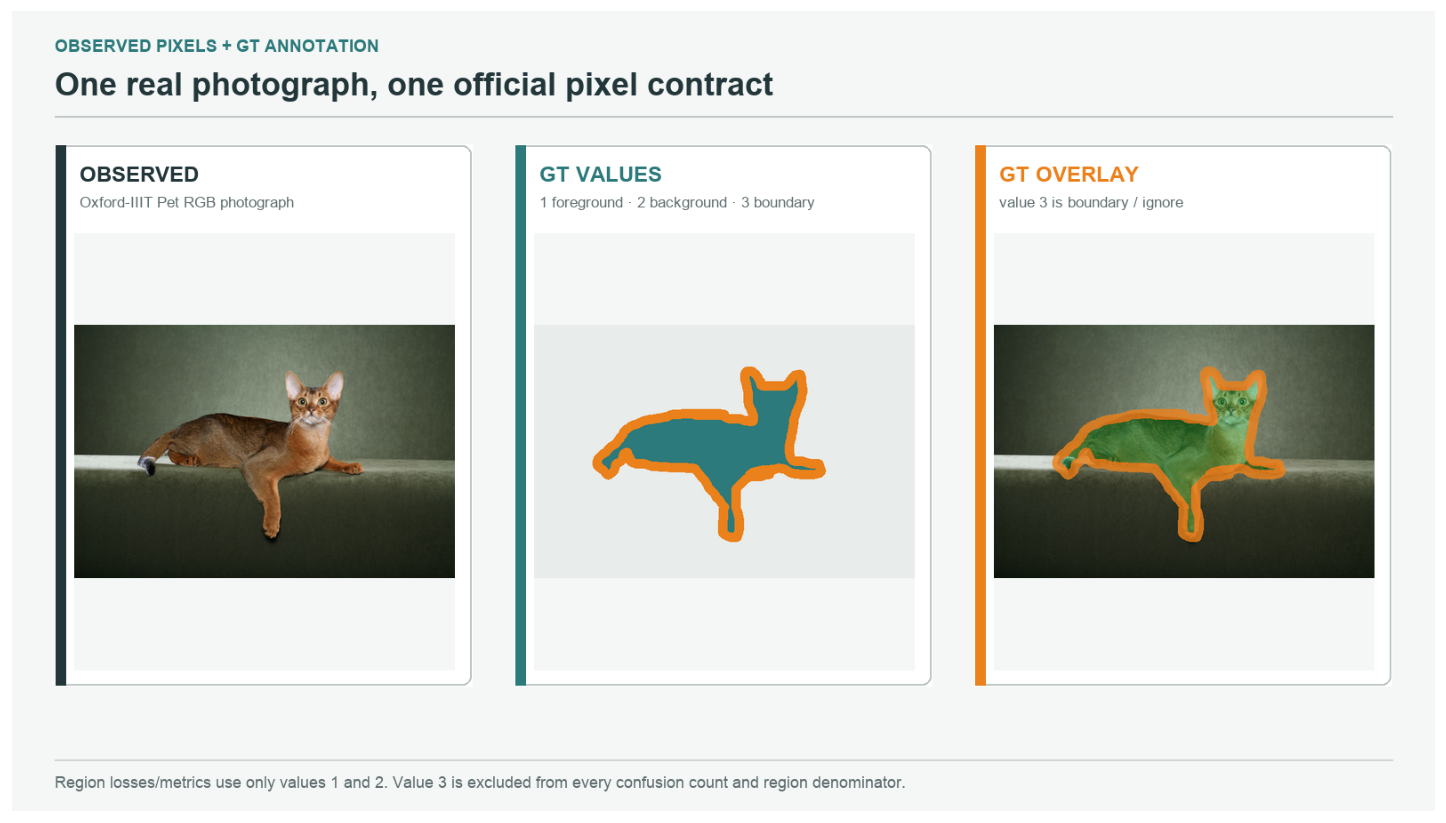

In [2]:
RAW_ROOT = 'https://raw.githubusercontent.com/nipunbatra/dl-teaching/master/'
ASSET_SPECS = {
    'manifest': ('shared/vision-evidence/oxford-iiit-pet/l10/evidence.json', 'b9d0a65cb38bf09253af5e072cee9bf46adfa3b50b9a5f91ef8ada98dc3bfa4a'),
    'metrics': ('shared/vision-evidence/oxford-iiit-pet/l10/metrics.csv', 'e4f50ebbc5b2a451495a40f601f2e34fe5fc025e7ed456e7f119c60d9e09d0ff'),
    'arrays': ('shared/vision-evidence/oxford-iiit-pet/l10/real-mask-arrays.npz', '47260e94e2704a0fc725ee65fbef0741c54c616113882429dde76324f4bb3906'),
    'contract_plate': ('shared/vision-evidence/oxford-iiit-pet/l10/real-trimap-contract.png', '09cde7df41acdfed4d4d3842216a1dcc5e212e758919c68b85dd4fab307fea7b'),
    'construction_plate': ('shared/vision-evidence/oxford-iiit-pet/l10/constructed-probability-mask.png', 'ed5ddf47ce115bb0ac0e989cce2cc19b8c2b96c7851844c26a90cf12e3e85fec'),
    'error_plate': ('shared/vision-evidence/oxford-iiit-pet/l10/real-error-overlay.png', '21077905a234b32e542fcb340e4921704f6f55edde098d7e30162a1fe9ac8fc6'),
    'audit_plate': ('shared/vision-evidence/oxford-iiit-pet/l10/region-boundary-audit.png', '3e21b2f96068d9b85df7ee025906596e64a115c9a99eab555bbf6599f1223623'),
    'photo': ('shared/vision-evidence/oxford-iiit-pet/Abyssinian_1.jpg', '2533197401eebe9410ea4d063f86c43fbd2666f3e8165a38aca155c0d09c21be'),
    'trimap': ('shared/vision-evidence/oxford-iiit-pet/Abyssinian_1-trimap.png', 'a39ce8ec0363178918cb257844125e3aa7773a3acd4ca8b84780d62c1fa6f220'),
}

def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def local_first(key):
    rel, expected = ASSET_SPECS[key]
    for root in (Path.cwd(), *Path.cwd().parents):
        candidate = root / rel
        if candidate.is_file():
            actual = sha256(candidate)
            assert actual == expected, f'{key}: local SHA mismatch {actual}'
            return candidate
    cache = Path(tempfile.gettempdir()) / 'dl-teaching-l10-evidence'
    cache.mkdir(parents=True, exist_ok=True)
    target = cache / Path(rel).name
    if not target.is_file() or sha256(target) != expected:
        urlretrieve(RAW_ROOT + rel, target)
    actual = sha256(target)
    assert actual == expected, f'{key}: downloaded SHA mismatch {actual}'
    return target

manifest = json.loads(local_first('manifest').read_text())
assert manifest['schema_version'] == 1
assert manifest['build']['builder_sha256'] == '57c614da0ebada58293032064e8c4ad5c8d2c0e396d3bb8a91d1771ce06247d7'
assert manifest['taxonomy']['model_output'] == []
assert manifest['taxonomy']['measured_performance'] == []

photo = plt.imread(local_first('photo'))
raw_trimap = plt.imread(local_first('trimap'))
if np.issubdtype(raw_trimap.dtype, np.floating):
    raw_trimap = np.rint(raw_trimap * 255).astype(np.uint8)
else:
    raw_trimap = raw_trimap.astype(np.uint8)
arrays = np.load(local_first('arrays'))
trimap = arrays['trimap']
valid_real = arrays['valid']
g_real = arrays['gt']
p_real = arrays['probability']
pred_real = arrays['prediction']

assert photo.shape[:2] == (400, 600)
assert np.array_equal(raw_trimap, trimap)
assert set(np.unique(trimap).tolist()) == {1, 2, 3}
assert np.array_equal(valid_real, trimap != 3)
assert np.array_equal(g_real, trimap == 1)
trimap_counts = {int(value): int((trimap == value).sum()) for value in (1, 2, 3)}
assert trimap_counts == {1: 22938, 2: 198766, 3: 18296}
print('OBSERVED: Oxford-IIIT Pet RGB photograph')
print('GT trimap counts (1 foreground, 2 background, 3 boundary/ignore):', trimap_counts)
print('CONSTRUCTED: +16 px probability field; COMPUTED: mask/metrics')
print('MODEL OUTPUT: none; MEASURED PERFORMANCE: none')

fig, ax = plt.subplots(figsize=(12, 6.75), constrained_layout=True)
ax.imshow(plt.imread(local_first('contract_plate')))
ax.axis('off')
plt.show()

### 0.1 · A controlled spatial error: shift GT foreground `+16 px`

Construct $p$ by shifting the official foreground right with zero fill, assigning `.90` to shifted foreground and `.10` elsewhere. Then compute $P=1[p\ge.50]$. The compact NPZ is the replay source; the notebook does **not** invoke the evidence builder.

**Predict before running:** Where should false negatives and false positives form? Can region IoU remain strong while a boundary diagnostic is poor?

valid/ignored pixels: 221,704 / 18,296
TP=18,736  FP=170  FN=4,202  TN=198,596
BCE=0.148690  Soft Dice=0.573856
IoU=0.810801  hard Dice=0.895517  accuracy=0.980280
These are COMPUTED diagnostics of a CONSTRUCTED shift, not measured model performance.


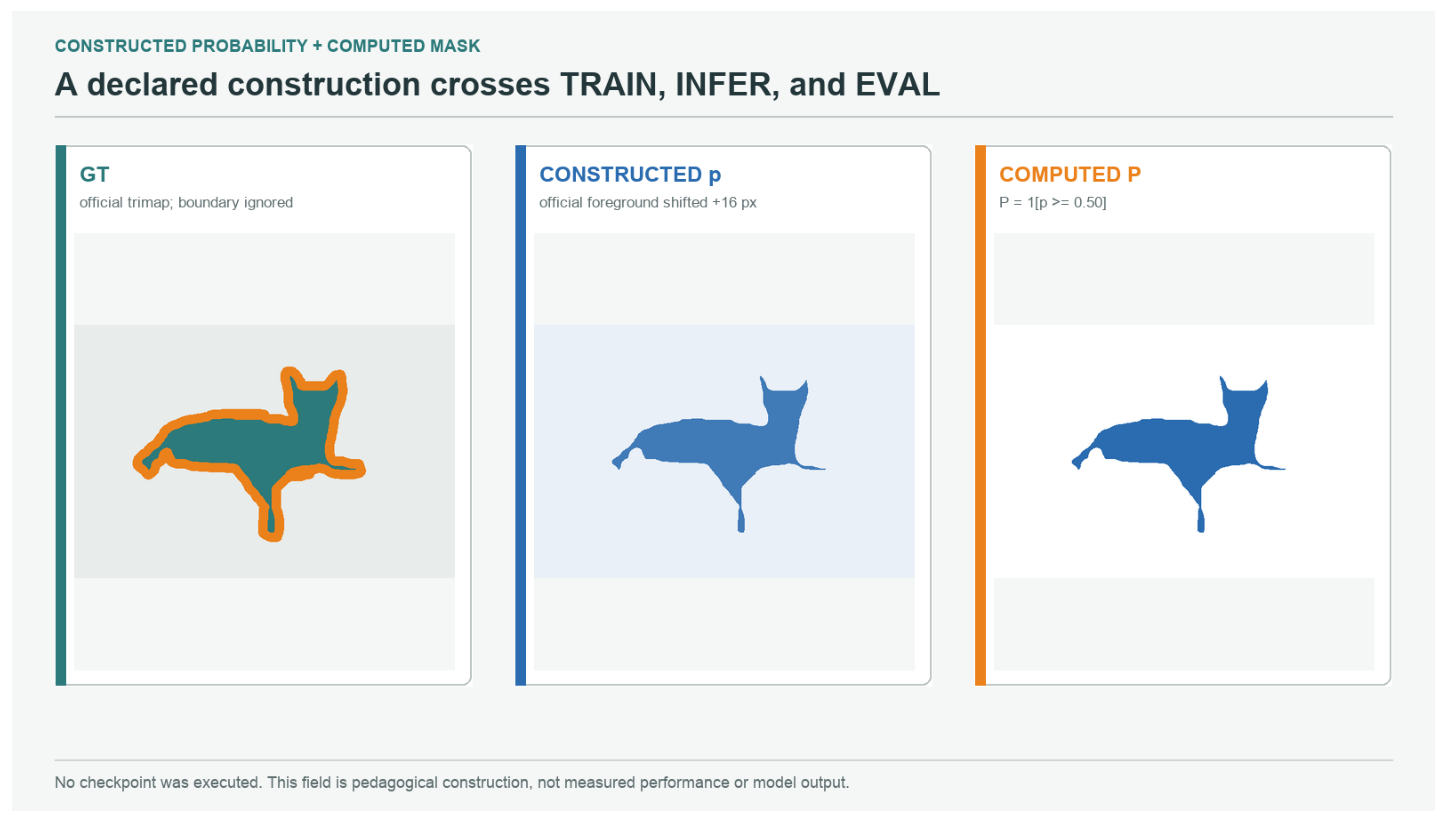

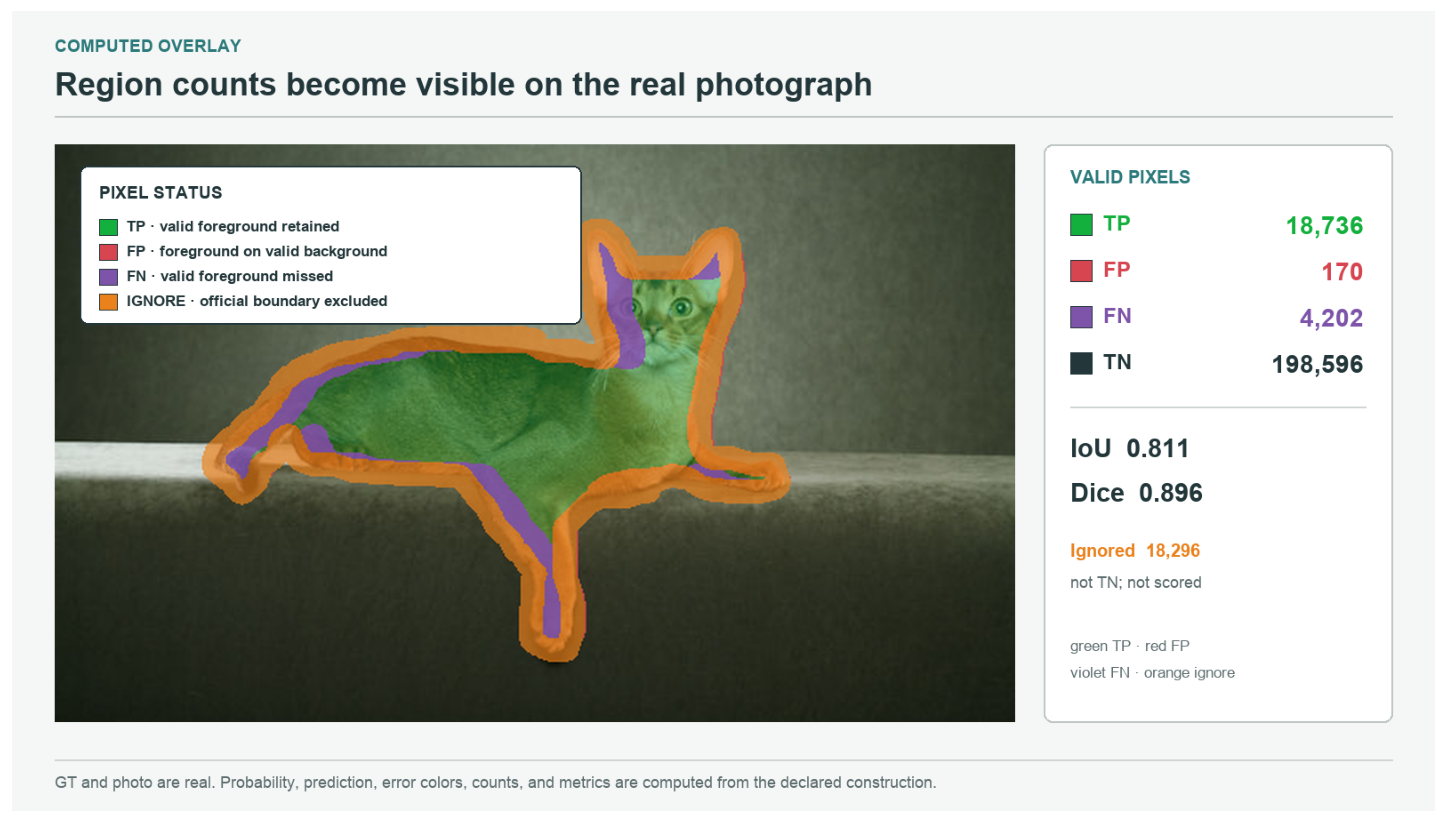

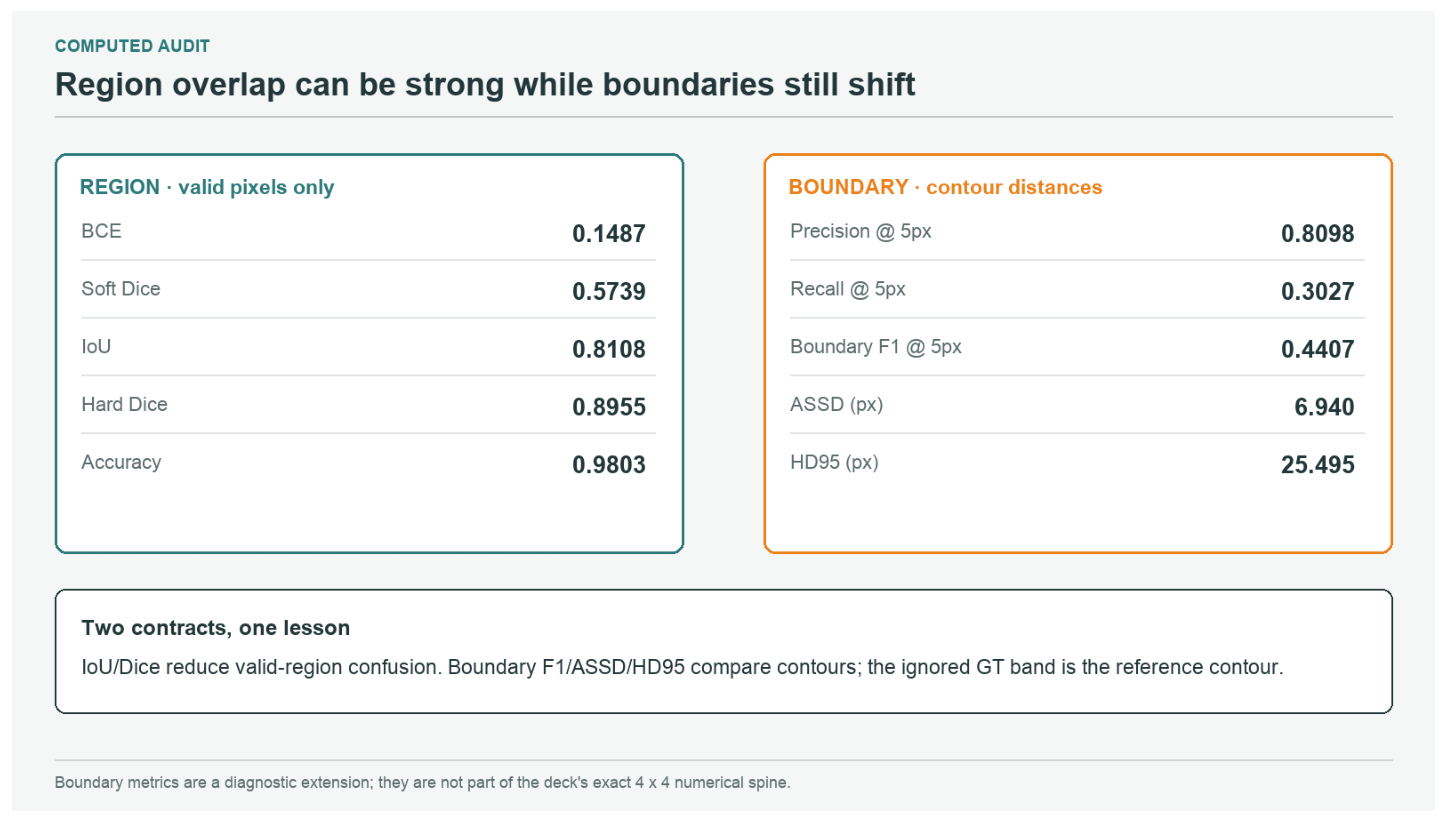

In [3]:
with local_first('metrics').open(newline='') as handle:
    metric_ledger = {row['metric']: float(row['value']) for row in csv.DictReader(handle)}

shifted_gt = np.zeros_like(g_real)
shifted_gt[:, 16:] = g_real[:, :-16]
expected_probability = np.where(shifted_gt, 0.90, 0.10)
assert np.array_equal(p_real, expected_probability)
assert np.array_equal(pred_real, p_real >= 0.50)

tp_real = int((g_real & pred_real & valid_real).sum())
fp_real = int((~g_real & pred_real & valid_real).sum())
fn_real = int((g_real & ~pred_real & valid_real).sum())
tn_real = int((~g_real & ~pred_real & valid_real).sum())
bce_real = float(-(g_real[valid_real] * np.log(p_real[valid_real]) +
                   (~g_real[valid_real]) * np.log1p(-p_real[valid_real])).mean())
soft_dice_real = float(2 * (p_real[valid_real] * g_real[valid_real]).sum() /
                       (p_real[valid_real].sum() + g_real[valid_real].sum()))
iou_real = tp_real / (tp_real + fp_real + fn_real)
hard_dice_real = 2 * tp_real / (2 * tp_real + fp_real + fn_real)
accuracy_real = (tp_real + tn_real) / int(valid_real.sum())

computed_real = {
    'tp': tp_real, 'fp': fp_real, 'fn': fn_real, 'tn': tn_real,
    'bce': bce_real, 'soft_dice': soft_dice_real, 'iou': iou_real,
    'hard_dice': hard_dice_real, 'accuracy': accuracy_real,
}
for key, value in computed_real.items():
    assert np.isclose(value, metric_ledger[key]), (key, value, metric_ledger[key])
assert (tp_real, fp_real, fn_real, tn_real) == (18736, 170, 4202, 198596)
assert int(valid_real.sum()) == 221704 and int((~valid_real).sum()) == 18296

print(f'valid/ignored pixels: {valid_real.sum():,} / {(~valid_real).sum():,}')
print(f'TP={tp_real:,}  FP={fp_real:,}  FN={fn_real:,}  TN={tn_real:,}')
print(f'BCE={bce_real:.6f}  Soft Dice={soft_dice_real:.6f}')
print(f'IoU={iou_real:.6f}  hard Dice={hard_dice_real:.6f}  accuracy={accuracy_real:.6f}')
print('These are COMPUTED diagnostics of a CONSTRUCTED shift, not measured model performance.')

for plate_key in ('construction_plate', 'error_plate', 'audit_plate'):
    fig, ax = plt.subplots(figsize=(12, 6.75), constrained_layout=True)
    ax.imshow(plt.imread(local_first(plate_key)))
    ax.axis('off')
    plt.show()

## 1 · One pixel: logits → softmax → cross-entropy

The classes are `background`, `road`, and `car`. For one pixel the network emits logits

$$z = (0.2,\;1.4,\;-0.3).$$

**Predict before running:** Which class wins? Will its probability be above or below 0.8? Why can the winning probability be below 0.8 even when its logit is the largest?

In [4]:
classes = np.array(["background", "road", "car"])
z = np.array([0.2, 1.4, -0.3])

def softmax(logits):
    shifted = logits - np.max(logits)
    weights = np.exp(shifted)
    return weights / weights.sum()

raw_exp_z = np.exp(z)  # safe here and retained to match the hand calculation
p = softmax(z)         # stable implementation used for probabilities
winner = str(classes[int(np.argmax(p))])
loss_if_road = float(-np.log(p[1]))

print("exp(z) for this toy vector:", raw_exp_z)
print("probabilities:", dict(zip(classes.tolist(), p.round(3).tolist())))
print("winner:", winner)
print(f"CE when the true class is road: {loss_if_road:.3f}")

assert np.isclose(p.sum(), 1.0)
assert np.allclose(p, raw_exp_z / raw_exp_z.sum())
assert np.allclose(p, softmax(z + 1000.0))  # softmax is shift-invariant and stays finite
assert np.allclose(p.round(3), [0.203, 0.674, 0.123])
assert winner == "road"
assert np.isclose(loss_if_road, 0.395, atol=1e-3)

exp(z) for this toy vector: [1.221 4.055 0.741]
probabilities: {'background': 0.203, 'road': 0.674, 'car': 0.123}
winner: road
CE when the true class is road: 0.395


**Explain:** Softmax compares all three class scores *at this pixel*. The road score wins, but the other two exponentiated scores still take probability mass.

**Explain:** The code subtracts the largest logit before exponentiating. That shift leaves softmax unchanged but prevents overflow for large logits. Then change only the road logit and explain why that is different from adding one constant to all logits.

## 2 · Dense cross-entropy is a mean over valid pixels

For a $2\times2$ crop, suppose the probabilities assigned to the **correct** class are

$$P_{\text{correct}}=\begin{bmatrix}0.80&0.60\\0.90&0.25\end{bmatrix}.$$

**Predict:** Which pixel contributes the largest loss? Estimate whether the mean CE is closer to 0.2, 0.6, or 1.2.

In [5]:
p_correct = np.array([[0.80, 0.60], [0.90, 0.25]])
pixel_losses = -np.log(p_correct)
dense_ce = float(pixel_losses.mean())
largest_index = tuple(int(i) for i in np.unravel_index(pixel_losses.argmax(), pixel_losses.shape))

print("per-pixel losses:\n", pixel_losses)
print(f"mean dense CE: {dense_ce:.3f}")
print("largest contribution at index:", largest_index)

assert np.allclose(pixel_losses, [[0.22314355, 0.51082562], [0.10536052, 1.38629436]])
assert np.isclose(dense_ce, 0.556, atol=1e-3)
assert largest_index == (1, 1)

per-pixel losses:
 [[0.223 0.511]
 [0.105 1.386]]
mean dense CE: 0.556
largest contribution at index: (1, 1)


A void/ignore pixel must be removed from both the sum **and** the denominator. In the next cell, the bottom-right pixel is ignored.

**Predict:** Does the valid-pixel mean become smaller or larger when that low-confidence pixel is ignored?

In [6]:
valid = np.array([[True, True], [True, False]])
valid_count = int(valid.sum())
valid_ce = float(pixel_losses[valid].mean())
print("valid pixels:", valid_count)
print(f"CE over valid pixels only: {valid_ce:.3f}")

assert valid_count == 3
assert np.isclose(valid_ce, 0.280, atol=1e-3)

valid pixels: 3
CE over valid pixels only: 0.280


## 3 · One constructed running $4\times4$ board mask

These are exactly the constructed hard masks used for the slide deck's hand calculations. They are separate from the Oxford annotation above and are not model output.

**Calculate before running:** Count TP, FP, FN, and TN. Then compute accuracy, IoU, and Dice by hand.

In [7]:
g = np.array([
    [0, 1, 1, 0],
    [0, 1, 1, 0],
    [0, 1, 1, 0],
    [0, 0, 0, 0],
])
pred = np.array([
    [0, 1, 1, 0],
    [1, 1, 1, 0],
    [0, 1, 0, 1],
    [0, 1, 0, 0],
])

def counts(y_true, y_pred):
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    return tp, fp, fn, tn

def hard_metrics(y_true, y_pred, *, empty_score=1.0):
    """Binary hard-mask metrics. Empty truth + empty prediction receives empty_score."""
    tp, fp, fn, tn = counts(y_true, y_pred)
    accuracy = (tp + tn) / (tp + fp + fn + tn)
    iou_denominator = tp + fp + fn
    dice_denominator = 2 * tp + fp + fn
    iou = float(empty_score) if iou_denominator == 0 else tp / iou_denominator
    dice = float(empty_score) if dice_denominator == 0 else 2 * tp / dice_denominator
    return {"TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "accuracy": accuracy, "IoU": iou, "Dice": dice}

m = hard_metrics(g, pred)
for key, value in m.items():
    print(f"{key:>8}: {value:.3f}" if isinstance(value, float) else f"{key:>8}: {value}")

assert counts(g, pred) == (5, 3, 1, 7)
assert np.isclose(m["accuracy"], 0.750)
assert np.isclose(m["IoU"], 5/9)
assert np.isclose(m["Dice"], 10/14)

      TP: 5
      FP: 3
      FN: 1
      TN: 7
accuracy: 0.750
     IoU: 0.556
    Dice: 0.714


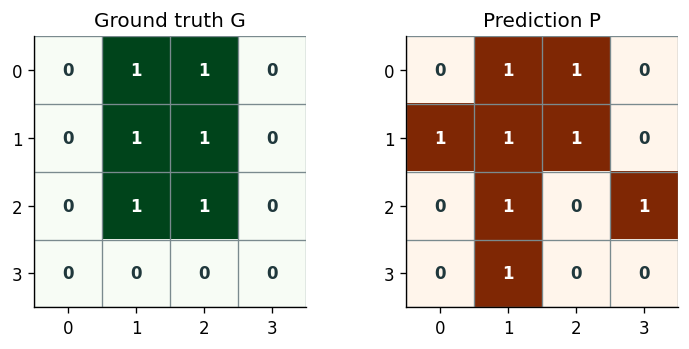

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(6.2, 2.8), constrained_layout=True)
for a, mask, title, cmap in zip(ax, [g, pred], ["Ground truth G", "Prediction P"], ["Greens", "Oranges"]):
    a.imshow(mask, vmin=0, vmax=1, cmap=cmap)
    a.set(title=title, xticks=range(4), yticks=range(4))
    a.set_xticks(np.arange(-.5, 4, 1), minor=True)
    a.set_yticks(np.arange(-.5, 4, 1), minor=True)
    a.grid(which="minor", color="#7a8a8e", linewidth=.8)
    a.tick_params(which="minor", bottom=False, left=False)
    for (r, c), v in np.ndenumerate(mask):
        label_color = "white" if int(v) == 1 else "#20383c"
        a.text(c, r, str(int(v)), ha="center", va="center", color=label_color, fontweight="bold")
plt.show()

## 4 · The all-background trap and the empty-mask protocol

**Predict:** If every foreground pixel is changed to background, what happens to accuracy, IoU, and Dice? Which metric still looks deceptively good when the foreground is very rare?

**Convention used here:** an empty truth paired with an empty prediction receives IoU = Dice = 1; an empty truth paired with any predicted foreground receives 0. This is not universal. A report must also say whether empty cases are included in, or excluded from, dataset/class averages.

In [9]:
all_background = np.zeros_like(g)
m_bg = hard_metrics(g, all_background)
print(f"4x4 all-background: accuracy={m_bg['accuracy']:.3f}, IoU={m_bg['IoU']:.3f}, Dice={m_bg['Dice']:.3f}")

# A more realistic severe-imbalance case: 100 foreground pixels in a 100x100 image.
large_g = np.zeros((100, 100), dtype=int)
large_g[:10, :10] = 1
large_pred = np.zeros_like(large_g)
large_m = hard_metrics(large_g, large_pred)
print(f"100x100 all-background: accuracy={large_m['accuracy']:.3f}, IoU={large_m['IoU']:.3f}, Dice={large_m['Dice']:.3f}")

empty_truth = np.zeros_like(g)
empty_prediction = np.zeros_like(g)
one_false_positive = np.zeros_like(g)
one_false_positive[0, 0] = 1
empty_empty = hard_metrics(empty_truth, empty_prediction)
empty_nonempty = hard_metrics(empty_truth, one_false_positive)
print(f"empty/empty policy: IoU={empty_empty['IoU']:.3f}, Dice={empty_empty['Dice']:.3f}")
print(f"empty truth + one FP: IoU={empty_nonempty['IoU']:.3f}, Dice={empty_nonempty['Dice']:.3f}")

assert counts(g, all_background) == (0, 0, 6, 10)
assert np.isclose(m_bg["accuracy"], 0.625) and m_bg["IoU"] == m_bg["Dice"] == 0.0
assert counts(large_g, large_pred) == (0, 0, 100, 9900)
assert np.isclose(large_m["accuracy"], 0.990) and large_m["IoU"] == large_m["Dice"] == 0.0
assert empty_empty["IoU"] == empty_empty["Dice"] == 1.0
assert empty_nonempty["IoU"] == empty_nonempty["Dice"] == 0.0

4x4 all-background: accuracy=0.625, IoU=0.000, Dice=0.000
100x100 all-background: accuracy=0.990, IoU=0.000, Dice=0.000
empty/empty policy: IoU=1.000, Dice=1.000
empty truth + one FP: IoU=0.000, Dice=0.000


## 5 · Change one true negative

Choose any location where both masks are 0 and flip only the prediction to 1.

**Predict first:** Accuracy, IoU, and Dice all decrease. Which formula reveals why true negatives never appear in IoU or Dice?

In [10]:
pred_one_more_fp = pred.copy()
pred_one_more_fp[0, 0] = 1  # this was a true negative

before = hard_metrics(g, pred)
after = hard_metrics(g, pred_one_more_fp)
for key in ["accuracy", "IoU", "Dice"]:
    print(f"{key:>8}: {before[key]:.3f} -> {after[key]:.3f}")

assert counts(g, pred_one_more_fp) == (5, 4, 1, 6)
assert np.isclose(after["accuracy"], 11/16)
assert np.isclose(after["IoU"], 5/10)
assert np.isclose(after["Dice"], 10/15)

accuracy: 0.750 -> 0.688
     IoU: 0.556 -> 0.500
    Dice: 0.714 -> 0.667


## 6 · Soft Dice uses probabilities before thresholding

We now use the slide deck's probability map. It has $\sum_i p_i=7.2$ and $\sum_i p_i g_i=4.8$; thresholding at $0.5$ recovers the same hard prediction $P$ above.

**Calculate before running:** Compute soft Dice and binary cross-entropy for this field. If probability mass moves from background pixels onto true foreground pixels while $\sum_i p_i$ stays fixed, does soft Dice rise or fall?

In [11]:
p_fg = np.array([
    [0.10, 0.90, 0.90, 0.10],
    [0.60, 0.90, 0.90, 0.10],
    [0.10, 0.90, 0.30, 0.60],
    [0.10, 0.60, 0.05, 0.05],
])

def soft_dice(prob, target, eps=1e-7):
    return (2 * (prob * target).sum() + eps) / (prob.sum() + target.sum() + eps)

p_sum = float(p_fg.sum())
g_sum = int(g.sum())
overlap_sum = float((p_fg * g).sum())
dice_soft = float(soft_dice(p_fg, g))
dice_loss = 1.0 - dice_soft
binary_ce = float(-(g * np.log(p_fg) + (1 - g) * np.log1p(-p_fg)).mean())
pred_from_probability = (p_fg >= 0.5).astype(int)

print(f"sum p:       {p_sum:.1f}")
print(f"sum g:       {g_sum}")
print(f"sum p*g:     {overlap_sum:.1f}")
print(f"soft Dice:   {dice_soft:.6f}")
print(f"Dice loss:   {dice_loss:.6f}")
print(f"binary CE:   {binary_ce:.3f}")
print("threshold 0.5 reproduces P:", bool(np.array_equal(pred_from_probability, pred)))

assert np.isclose(p_sum, 7.2)
assert g_sum == 6
assert np.isclose(overlap_sum, 4.8)
assert np.isclose(dice_soft, 9.6/13.2)
assert np.isclose(dice_loss, 1 - 9.6/13.2)
assert np.isclose(binary_ce, 0.319, atol=1e-3)
assert np.array_equal(pred_from_probability, pred)
assert counts(g, pred_from_probability) == (5, 3, 1, 7)

sum p:       7.2
sum g:       6
sum p*g:     4.8
soft Dice:   0.727273
Dice loss:   0.272727
binary CE:   0.319
threshold 0.5 reproduces P: True


## 7 · A tiny instance-mask BCE

For one **matched positive RoI** and the selected ground-truth class, original Mask R-CNN trains a binary mask. Negative RoIs have no mask target and contribute no mask loss.

$$M=\begin{bmatrix}1&1\\0&0\end{bmatrix},\qquad \hat M=\begin{bmatrix}0.8&0.6\\0.3&0.1\end{bmatrix}.$$

**Calculate:** Write the four BCE terms before running the cell. Which pixel is the largest penalty?

In [12]:
roi_target = np.array([[1., 1.], [0., 0.]])
roi_prob = np.array([[0.8, 0.6], [0.3, 0.1]])
roi_bce_terms = -(roi_target * np.log(roi_prob) + (1 - roi_target) * np.log(1 - roi_prob))
roi_bce = float(roi_bce_terms.mean())
print("per-pixel BCE:\n", roi_bce_terms)
print(f"mean mask BCE: {roi_bce:.3f}")
assert np.allclose(roi_bce_terms, [[0.22314355, 0.51082562], [0.35667494, 0.10536052]])
assert np.isclose(roi_bce, 0.299, atol=1e-3)

per-pixel BCE:
 [[0.223 0.511]
 [0.357 0.105]]
mean mask BCE: 0.299


## Final explain-back

Without looking back, answer in complete sentences:

1. Which real-case objects are observed, GT, constructed, and computed—and why is none of them model output?
2. Why must trimap value `3` be removed from every region numerator and denominator?
3. Why does softmax normalize over classes rather than over pixels?
4. Why can all-background prediction have excellent accuracy and zero Dice?
5. Why do neither IoU nor Dice contain TN?
6. Why does the original Mask R-CNN mask loss update only one of its $K$ mask channels for a matched positive RoI?
7. If a dataset contains empty masks, what score and averaging convention must be stated when reporting Dice?

A strong answer connects each metric or loss to the **output structure and question being asked**, not only to its formula.